In [11]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    build_combined_feature_frame,
    create_pipeline,
    get_feature_names_from_pipeline,
    plot_confusion_matrix_for_model,
    plot_model_feature_importance,
    plot_permutation_importance_for_model,
    plot_roc_curve_for_model,
    plot_shap_summary_for_model,
    run_interpretability_suite,
    run_model_experiment,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imblearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import shap


In [12]:
# Shared feature extraction moved into build_combined_feature_frame().

# Build a binary adverse neonatal outcome.
# 1 = low birth weight, preterm, or low Apgar (0-3 on 1m, 5m, or 10m)
# 0 = none of the above
df_birth = pd.read_csv('../../Data/CBA.csv', encoding='latin-1', low_memory=False)
df_birth = df_birth[['PublicID', 'CBAA04a', 'CBAA04b', 'CBAA04c', 'CBAA05a_Gm']]
df_birth[['CBAA04a', 'CBAA04b', 'CBAA04c', 'CBAA05a_Gm']] = df_birth[['CBAA04a', 'CBAA04b', 'CBAA04c', 'CBAA05a_Gm']].apply(pd.to_numeric, errors='coerce')

df_outcomes = pd.read_csv('../../Data/PREGNANCY_OUTCOMES.csv', usecols=['PublicID', 'GAwksCA'])
df_outcomes['GAwksCA'] = pd.to_numeric(df_outcomes['GAwksCA'], errors='coerce')

outcome_df = pd.merge(df_birth, df_outcomes, on='PublicID', how='left')
low_birth_weight_mask = outcome_df['CBAA05a_Gm'].notna() & (outcome_df['CBAA05a_Gm'] <= 2500)
preterm_mask = outcome_df['GAwksCA'].notna() & (outcome_df['GAwksCA'] < 36)
low_apgar_mask = outcome_df[['CBAA04a', 'CBAA04b', 'CBAA04c']].apply(lambda s: s.between(0, 3, inclusive='both')).any(axis=1)
observed_mask = outcome_df[['CBAA05a_Gm', 'GAwksCA', 'CBAA04a', 'CBAA04b', 'CBAA04c']].notna().any(axis=1)

outcome_df['Low_Birth_Weight'] = pd.Series(pd.NA, index=outcome_df.index, dtype='Int64')
outcome_df.loc[outcome_df['CBAA05a_Gm'].notna(), 'Low_Birth_Weight'] = low_birth_weight_mask.loc[outcome_df['CBAA05a_Gm'].notna()].astype('Int64')
outcome_df['Preterm_Birth_Category'] = pd.Series(pd.NA, index=outcome_df.index, dtype='Int64')
outcome_df.loc[outcome_df['GAwksCA'].notna(), 'Preterm_Birth_Category'] = preterm_mask.loc[outcome_df['GAwksCA'].notna()].astype('Int64')
outcome_df['Low_Apgar_Category'] = pd.Series(pd.NA, index=outcome_df.index, dtype='Int64')
low_apgar_observed = outcome_df[['CBAA04a', 'CBAA04b', 'CBAA04c']].notna().any(axis=1)
outcome_df.loc[low_apgar_observed, 'Low_Apgar_Category'] = low_apgar_mask.loc[low_apgar_observed].astype('Int64')

# Birth type mapping is intentionally commented out for now.
# value_mapping = {
#     'sFTLB': 0, 'iFTLB': 0, 'ddddd': 0, 'sPTLB': 0, 'iPTLB': 0,
#     'dFTLB': 0, 'iPTSB': 1, 'iFTSB': 1, 'sPTSB': 1, 'dddLB': 0,
#     'dddSB': 1, 'dFTSB': 1, 'dPTSB': 1, 'sFTSB': 1, 'dPTLB': 0,
# }
# outcome_df['Birth_Type'] = pd.read_csv('../../Data/PREGNANCY_OUTCOMES.csv', usecols=['PublicID', 'TYPE_CA_A09'])['TYPE_CA_A09'].map(value_mapping)

outcome_df['Adverse_Neonatal_Outcome'] = pd.Series(pd.NA, index=outcome_df.index, dtype='Int64')
outcome_df.loc[observed_mask & ~(low_birth_weight_mask | preterm_mask | low_apgar_mask), 'Adverse_Neonatal_Outcome'] = 0
outcome_df.loc[low_birth_weight_mask | preterm_mask | low_apgar_mask, 'Adverse_Neonatal_Outcome'] = 1
outcome_df = outcome_df.drop_duplicates(subset=['PublicID'])
outcome_labels = outcome_df[['PublicID', 'Adverse_Neonatal_Outcome']].drop_duplicates(subset=['PublicID'])

outcome_df[['Adverse_Neonatal_Outcome', 'Low_Birth_Weight', 'Preterm_Birth_Category', 'Low_Apgar_Category']].value_counts(dropna=False)


Adverse_Neonatal_Outcome  Low_Birth_Weight  Preterm_Birth_Category  Low_Apgar_Category
0                         0                 0                       0                     7204
1                         0                 0                       1                      340
0                         <NA>              0                       0                      281
1                         1                 1                       0                      268
                                            0                       0                      231
                          0                 1                       0                      102
                          1                 1                       1                       55
0                         0                 0                       <NA>                    22
1                         1                 0                       1                       13
                          0                 1             

In [13]:
combined_inputs = build_combined_feature_frame(
    data_dir=Path('../../Data'),
    include_outcome=False,
    include_paternal=False,
    include_drugs=False,
    include_food=False,
    include_health_knowledge=False,
    include_mother_demo=False,
    include_physical_activity=False,
    include_sleep=False,
)
feature_lists = combined_inputs['feature_lists']
numeric_features = feature_lists['numeric_features']
categorical_features = feature_lists['categorical_features']
ordinal_features = feature_lists['ordinal_features']
binary_features = feature_lists['binary_features']
feature_columns = feature_lists['feature_columns']
combined_df = combined_inputs['combined_df']
outcome_df = outcome_df[['PublicID', 'Adverse_Neonatal_Outcome']].dropna().drop_duplicates(subset=['PublicID'])
combined_df = combined_df.merge(outcome_df, on='PublicID', how='inner')

split_frame = outcome_df[['PublicID', 'Adverse_Neonatal_Outcome']].dropna().drop_duplicates(subset=['PublicID'])
train_ids, test_ids = train_test_split(
    split_frame['PublicID'],
    test_size=0.2,
    random_state=42,
    stratify=split_frame['Adverse_Neonatal_Outcome'],
)

X = combined_df[feature_columns]
y = combined_df['Adverse_Neonatal_Outcome']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['Adverse_Neonatal_Outcome', 'PublicID'], axis=1)
X_test = test_df.drop(['Adverse_Neonatal_Outcome', 'PublicID'], axis=1)
y_train = train_df['Adverse_Neonatal_Outcome']
y_test = test_df['Adverse_Neonatal_Outcome']

outcome_df['Adverse_Neonatal_Outcome'].value_counts(dropna=False)


Adverse_Neonatal_Outcome
0    7517
1    1044
Name: count, dtype: Int64

In [14]:
# LR block using all domain features, with mother demographics split into numeric and categorical inputs.
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)


Dropping rows with missing values because impute=False (train: 1228, test: 262).
Final dataset sizes for LR (impute=False): train=5620, test=1451
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model

Best parameters found: {'classifier__C': 1, 'classifier__l1_ratio': 0.0}
Best CV Score (f1): 0.2395
Model Coefficients:
num__ResilienceTotalScore: 0.12748586152762764
num__stress_average: 0.037828037458244174
num__FrequencyOfHassles: -0.24156540100207755
num__FrequencyOfUplifts: 0.30857202105913223
num__IntensityOfHassles: 0.042505644973517165
num__IntensityOfUplifts: -0.10901808804773545
num__HassleUpliftFrequencyRatio: 0.6119990377354373
num__HassleUpliftIntensityRatio: -0.02388159859355694
num__StressTotalScore: 0.0923804379931091
bin__ChronHTN: -0.31902945966406704
bin__ResilienceLevel: 0.1150261429472302
bin__StressLevel: 0.013844992137232653
cat__oDM_1.0: 1.0585925151415287
cat__oDM_2.0: -0.37255893273666746
cat__oDM_3.0: -0.023230495204185426
cat__acog_PEgHTN_1.0: 0.36404709673660207
cat__acog_PEgHTN_2.0: 1.744000140792641
cat__acog_PEgHTN_3.0: 1.4471270082190975
cat__acog_PEgHTN_4.0: -1.04027833394825
cat__acog_PEgHTN_5.0: -0.6632671159770864
cat__acog_PEgHTN_6.0: -0.5965863901

In [15]:
# RF block using all domain features, with mother demographics split into numeric and categorical inputs.
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)


Dropping rows with missing values because impute=False (train: 1228, test: 262).
Final dataset sizes for RF (impute=False): train=5620, test=1451
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 500}
Best CV Score (f1): 0.2194
Feature Importances:
num__ResilienceTotalScore: 0.0689545099572997
num__stress_average: 0.13374348103239211
num__FrequencyOfHassles: 0.0010143604235835159
num__FrequencyOfUplifts: 0.0008233311067168518
num__IntensityOfHassles: 0.09255431800281755
num__IntensityOfUplifts: 0.08682288877309491
num__HassleUpliftFrequencyRatio: 0.0011592104057697467
num__HassleUpliftIntensityRatio: 0.07270275981050478
num__StressTotalScore: 0.12096210580303268
bin__ChronHTN: 0.025419414640426848
bin__ResilienceLevel: 0.01806692962070541
bin__StressLevel: 0.04555197183577783
cat__oDM_1.0: 0.014558487610475426
cat__oDM_2.0: 

In [16]:
# XGBoost block using all domain features, with mother demographics split into numeric and categorical inputs.
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)


Dropping rows with missing values because impute=False (train: 1228, test: 262).
Final dataset sizes for XGB (impute=False): train=5620, test=1451
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.001, 'classifier__max_depth': 6, 'classifier__n_estimators': 80, 'classifier__subsample': 0.5}
Best CV Score (f1): 0.2558
Feature Importances:
num__ResilienceTotalScore: 0.007991788908839226
num__stress_average: 0.05623987689614296
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.024599503725767136
num__IntensityOfUplifts: 0.008250721730291843
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.007931387983262539
num__StressTotalScore: 0.021961567923426628
bin__ChronHTN: 0.07704140990972519
bin__ResilienceLevel: 0.0161094032227993
bin__StressLevel: 0.03582252562046051
cat__oDM_1.0: 0.0221639983355999
cat__oDM_2.0: 0.01711029559373855

In [18]:
# SVM block using all domain features, with mother demographics split into numeric and categorical inputs.
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features
)


Dropping rows with missing values because impute=False (train: 1228, test: 262).
Final dataset sizes for SVM (impute=False): train=5620, test=1451
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 100, 'classifier__estimator__kernel': 'linear'}
Best CV Score (f1): 0.2415
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.8436
Precision (positive class): 0.2500
Recall (positive class): 0.1796
F1 (positive class): 0.2091
Macro Precision: 0.5735
Macro Recall: 0.5548
Macro F1: 0.5611
ROC AUC: 0.5677


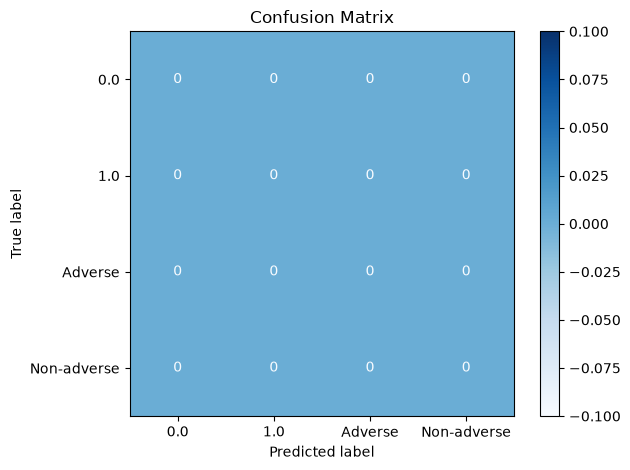

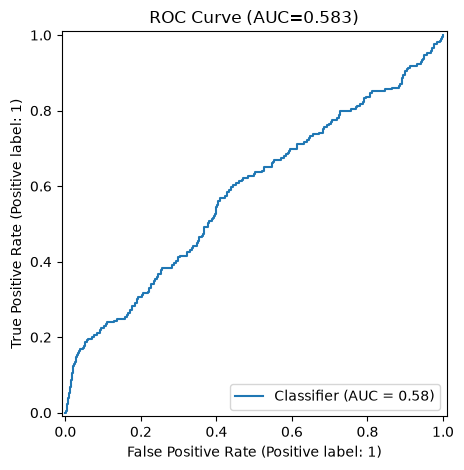

Feature importance skipped: model does not expose coefficients or feature_importances_.


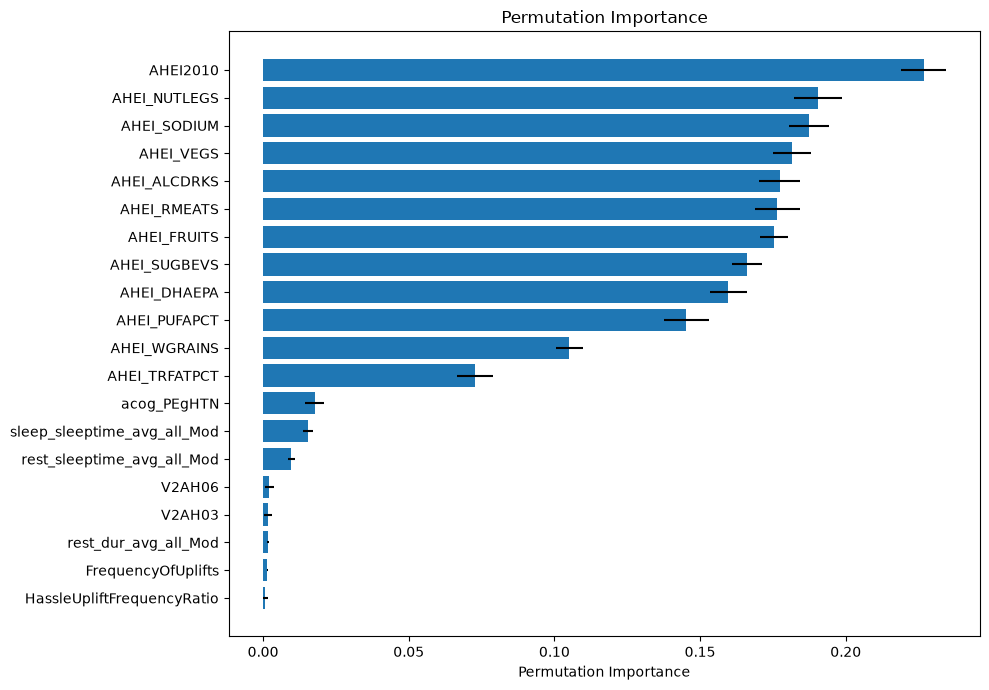

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: The passed model is not callable and cannot be analyzed directly with the given masker! Model: CalibratedClassifierCV(ensemble=False, estimator=SVC(C=10, kernel='linear'))


In [ ]:
# Interpretability for the XGB baby-health model.
# Swap xgb_model for lr_model, rf_model, or svm_model if you want a different view.
run_interpretability_suite(svm_model, X_train, X_test, y_test, labels=['Non-adverse', 'Adverse'], top_n=20)